Import libraries

In [2]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt

import collections

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.optimizers import Adam

import pathlib

from sklearn.metrics import classification_report, confusion_matrix




Autotune Data

In [6]:
# Configuration Variables.
autotune = tf.data.AUTOTUNE
batch_size = 32
img_size = (150, 150)
class_names = ['normal', 'pneumonia', 'tuberculosis']
buffer_size = 10000

In [3]:
# Dataset Path
data_root = pathlib.Path( r"/Users/michaelperrine/Library/CloudStorage/OneDrive-Personal/Documents/Bellevue/Applied Data Science/Project 3/archive")

In [4]:
# Data Subdirectories.
train_dir = data_root/'train'
val_dir = data_root/'val'
test_dir = data_root/'test'

In [7]:
# Load Datasets.
train_ds =tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size = img_size,
    color_mode = 'grayscale',
    batch_size = batch_size,
    shuffle = True
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    image_size = img_size,
    color_mode = 'grayscale',
    batch_size = batch_size,
    shuffle =False
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size = img_size,
    color_mode = 'grayscale',
    batch_size = batch_size,
    shuffle = False
)

print('Inferred Class Names:', class_names)
num_classes = len(class_names)

Found 20450 files belonging to 3 classes.
Found 2534 files belonging to 3 classes.
Found 2569 files belonging to 3 classes.
Inferred Class Names: ['normal', 'pneumonia', 'tuberculosis']


2025-11-18 08:22:34.437653: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2025-11-18 08:22:34.437691: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2025-11-18 08:22:34.437695: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.00 GB
2025-11-18 08:22:34.437883: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-11-18 08:22:34.437892: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [8]:
# Optimize Dataset Performance.
train_ds = train_ds.cache().shuffle(buffer_size).prefetch(buffer_size = autotune)
val_ds = val_ds.cache().prefetch(buffer_size = autotune)
test_ds = test_ds.cache().prefetch(buffer_size = autotune)


Calculate class weights to handle class imbalance

In [9]:
# Calculate Class Weights to handle class imbalance.
class_counts = collections.Counter()

for _, labels in train_ds:
    class_counts.update(labels.numpy().tolist())
print('Class Counts:', class_counts)

normal_iamage_count = class_counts[0]
pneumonia_image_count = class_counts[1]
tuberculosis_image_count = class_counts[2]
total_image_count = sum(class_counts.values())

weight_for_normal = total_image_count / (3 * normal_iamage_count)
weight_for_pneumonia = total_image_count / (3 * pneumonia_image_count)
weight_for_tuberculosis = total_image_count / (3 * tuberculosis_image_count)
class_weight = {
    0: weight_for_normal, 
    1: weight_for_pneumonia, 
    2: weight_for_tuberculosis}

print('Class Weights:' , class_weight)

    

Class Counts: Counter({2: 8513, 0: 7263, 1: 4674})
Class Weights: {0: 0.9385469732433797, 1: 1.4584224789616318, 2: 0.8007361290575199}


2025-11-18 08:22:52.461709: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Visualize Data

2025-11-18 08:22:54.697586: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


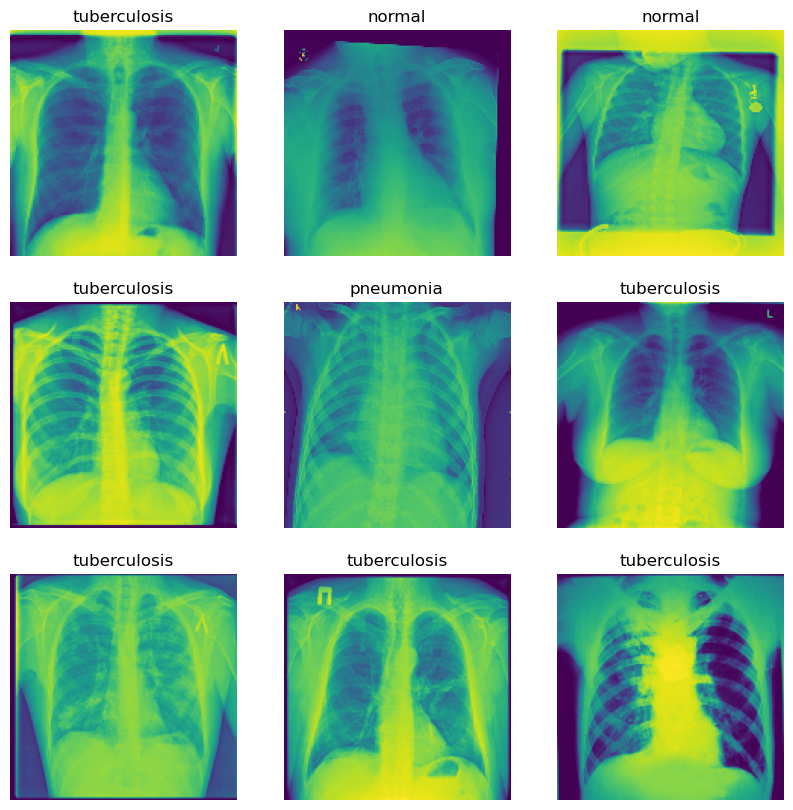

In [10]:
# Visualize Sample Images from the Training Set.
plt.figure(figsize=(10,10))
for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(np.squeeze(images[i].numpy().astype('uint8')))
        plt.title(class_names[labels[i]])
        plt.axis('off')

Build CNN

In [ ]:
# Build the CNN Model.
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
])

inputs = tf.keras.Input(shape = img_size + (1,))
x = data_augmentation(inputs)
x = tf.keras.layers.Rescaling(1./255)(x)

x = tf.keras.layers.Conv2D(32, (3, 3), activation = 'relu', padding = 'same')(x)
x = tf.keras.layers.MaxPooling2D()(x)

x = tf.keras.layers.Conv2D(64, (3, 3), activation = 'relu', padding = 'same')(x)
x = tf.keras.layers.MaxPooling2D()(x)

x = tf.keras.layers.Conv2D(128, (3, 3), activation = 'relu', padding = 'same')(x)
x = tf.keras.layers.MaxPooling2D()(x)

x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.5)(x)
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(128, activation = 'relu')(x)

outputs = tf.keras.layers.Dense(num_classes, activation = 'sigmoid')(x)

model = tf.keras.Model(inputs = inputs, outputs = outputs)


In [ ]:
# Compile the Model.
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate = 1e-4),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 150, 150, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 150, 150, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,571 (428.01 KB)

 Trainable params: 109,571 (428.01 KB)

 Non-trainable params: 0 (0.00 B)

Train Model

In [ ]:
# Train the Model with class weights.
history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 20,
    class_weight = class_weight
)

Epoch 1/20


2025-11-17 10:32:48.566840: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


640/640 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - accuracy: 0.4047 - loss: 1.0831 - val_accuracy: 0.5339 - val_loss: 1.0194
Epoch 2/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.5437 - loss: 0.9243 - val_accuracy: 0.5777 - val_loss: 0.8555
Epoch 3/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 18s 27ms/step - accuracy: 0.5730 - loss: 0.8125 - val_accuracy: 0.5872 - val_loss: 0.8102
Epoch 4/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.5749 - loss: 0.7855 - val_accuracy: 0.6022 - val_loss: 0.7774
Epoch 5/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.5870 - loss: 0.7675 - val_accuracy: 0.6073 - val_loss: 0.7586
Epoch 6/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 18s 27ms/step - accuracy: 0.5911 - loss: 0.7588 - val_accuracy: 0.6073 - val_loss: 0.7594
Epoch 7/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.5920 - loss: 0.7523 - val_accuracy: 0.6026 - val_loss: 0.7713
Epoch 8/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.5955 - loss: 0.7502 - val_accurac

Evaluate

In [ ]:
# Evaluate the model.
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Accuracy: {test_accuracy:.4f}")

81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5889 - loss: 0.7578
Test Accuracy: 0.5889


In [ ]:
# Save the model.
model.save('xray classification_model1.keras')

Build Second Model to test improvements in model

2025-11-18 08:23:05.350039: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


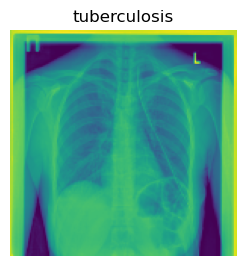

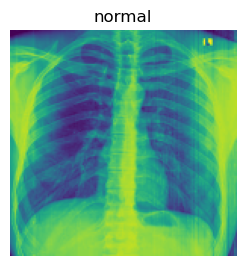

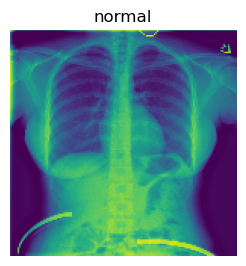

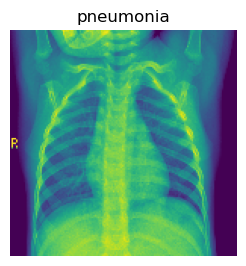

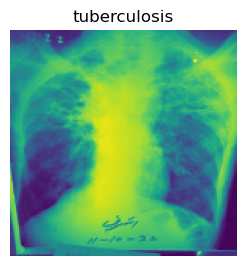

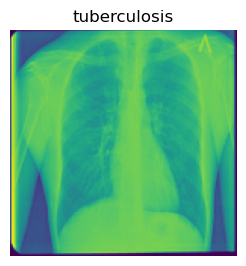

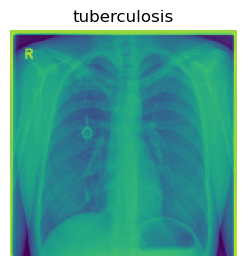

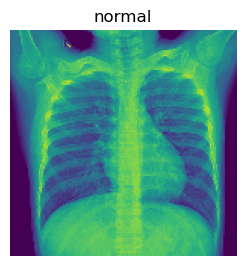

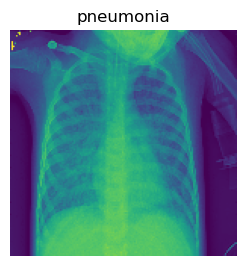

In [ ]:
# Visualize sample images from the training set.
for images, labels in train_ds.take(1):
    for i in range(9):
        plt.figure(figsize=(10, 10))         
        plt.subplot(3, 3 , i + 1)
        plt.imshow(np.squeeze(images[i].numpy().astype('uint8')))
        plt.title(class_names[labels[i]])
        plt.axis('off')
    

Reload data with new size

In [ ]:
# Reload dataset with differnt parameters.
img_size2 = (224, 224)
batch_size2 = 32
num_classes2 = len(class_names)

train_ds2 = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size = img_size2,
    color_mode = 'grayscale',
    batch_size = batch_size2,
    shuffle = True
)

val_ds2 = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    image_size = img_size2,
    color_mode = 'grayscale',
    batch_size = batch_size2,
    shuffle = False
)

test_ds2 = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size = img_size2,
    color_mode = 'grayscale',
    batch_size = batch_size2,
    shuffle = False
)
print('Inferred Class Names:', class_names)

Found 20450 files belonging to 3 classes.
Found 2534 files belonging to 3 classes.
Found 2569 files belonging to 3 classes.
Inferred Class Names: ['normal', 'pneumonia', 'tuberculosis']


In [ ]:
# Optimize dataset performance.
Autotune = tf.data.AUTOTUNE
train_ds2 = train_ds2.cache().shuffle(buffer_size).prefetch(buffer_size = Autotune)
val_ds2 = val_ds2.cache().prefetch(buffer_size = Autotune)
test_ds2 = test_ds2.cache().prefetch(buffer_size = Autotune)

data_augmentation2 = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1)
])


Pretrained backbone

In [ ]:
# Build the model using transfer learning.
base_model = tf.keras.applications.EfficientNetB0(
    include_top = False,
    input_shape = img_size2 + (3,),
    weights = 'imagenet'
)
# Freeze the base model
base_model.trainable = False
# Reload data with new size
inputs2 = tf.keras.Input(shape = img_size2 + (1,))
x2 = data_augmentation2(inputs2)
# Rescale grayscale to 3 channels
x2 = tf.keras.layers.Rescaling(1./255)(x2)
# Convert grayscale to RGB by repeating channels
x2 = tf.keras.layers.Concatenate()([x2, x2, x2])

x2 =  base_model(x2, training =False)
x2 = tf.keras.layers.GlobalAveragePooling2D()(x2)
x2 = tf.keras.layers.Dropout(0.4)(x2)
x2 = tf.keras.layers.Flatten()(x2)
outputs2 = tf.keras.layers.Dense(num_classes2, activation = 'sigmoid')(x2)

Build Model

In [ ]:
# Compile the model.
model2 = tf.keras.Model(inputs2, outputs2)
model2.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate = 1e-3),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [ ]:
# Fine-tune the model by unfreezig some layers of the base model.
base_model.trainable = True
for layer in base_model.layers[:100]:
    layer.trainable = False

# Continue with training model2
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate = 1e-6),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

Tune training setup

In [ ]:
# Set up callbacks for early stopping and learning rate reduction.
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor = 'val_loss',
        patience = 5,
        restore_best_weights = True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor = 'val_loss',
        factor = 0.5,
        patience = 2,
        min_lr = 1e-6
    )
]

history2 = model2.fit(
    train_ds2,
    validation_data = val_ds2,
    epochs = 30,
    class_weight = class_weight,
    callbacks = callbacks
)

Epoch 1/30
640/640 ━━━━━━━━━━━━━━━━━━━━ 158s 247ms/step - accuracy: 0.6284 - loss: 0.6880 - val_accuracy: 0.4199 - val_loss: 1.8841 - learning_rate: 0.0010
Epoch 2/30
640/640 ━━━━━━━━━━━━━━━━━━━━ 155s 242ms/step - accuracy: 0.6688 - loss: 0.6051 - val_accuracy: 0.7009 - val_loss: 0.6163 - learning_rate: 0.0010
Epoch 3/30
640/640 ━━━━━━━━━━━━━━━━━━━━ 154s 241ms/step - accuracy: 0.6977 - loss: 0.5530 - val_accuracy: 0.6614 - val_loss: 0.6145 - learning_rate: 0.0010
Epoch 4/30
640/640 ━━━━━━━━━━━━━━━━━━━━ 154s 241ms/step - accuracy: 0.7185 - loss: 0.5136 - val_accuracy: 0.6523 - val_loss: 0.6694 - learning_rate: 0.0010
Epoch 5/30
640/640 ━━━━━━━━━━━━━━━━━━━━ 155s 242ms/step - accuracy: 0.7303 - loss: 0.4880 - val_accuracy: 0.7151 - val_loss: 0.5692 - learning_rate: 0.0010
Epoch 6/30
640/640 ━━━━━━━━━━━━━━━━━━━━ 156s 243ms/step - accuracy: 0.7349 - loss: 0.4770 - val_accuracy: 0.5576 - val_loss: 1.6880 - learning_rate: 0.0010
Epoch 7/30
640/640 ━━━━━━━━━━━━━━━━━━━━ 559s 874ms/step - accura

In [ ]:
# Evauate the fine-tuned model.
test_loss, test_accuracy = model2.evaluate(test_ds2)
print(f"Test Accuracy : {test_accuracy: .4f}")

81/81 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - accuracy: 0.7657 - loss: 0.4279
Test Accuracy :  0.7657


In [ ]:
# Save the fine-tuned model.
model2.save('xray_2.keras')